# Chapter 8 — Approximation Theory

This session covers two key topics from §8.2–8.3 and §8.6 of Burden & Burden:

| Topic | Core question |
|-------|---------------|
| **Chebyshev Polynomials** | Among all degree-$n$ monic polynomials, which one is *smallest* on $[-1,1]$? How do their zeros minimise interpolation error? |
| **Fast Fourier Transform** | Given $N$ equally-spaced data points, how do we find the best trigonometric interpolant in $O(N\log N)$ instead of $O(N^2)$? |

---
## Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from numpy.polynomial.chebyshev import chebpts1, chebpts2, chebfit, chebval

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

---
## Part 1 — Chebyshev Polynomials

### 1.1  Definition

The **Chebyshev polynomial of the first kind** of degree $n$ is

$$T_n(x) = \cos\!\bigl(n\arccos x\bigr), \qquad x\in[-1,1].$$

The substitution $x=\cos\theta$ turns this into the simple identity
$T_n(\cos\theta)=\cos(n\theta)$, which is the gateway to almost every
property below.

**First few polynomials** (derivable directly from $\cos(n\theta)$ or
from the recurrence):

| $n$ | $T_n(x)$ |
|-----|----------|
| 0 | $1$ |
| 1 | $x$ |
| 2 | $2x^2-1$ |
| 3 | $4x^3-3x$ |
| 4 | $8x^4-8x^2+1$ |
| 5 | $16x^5-20x^3+5x$ |

### 1.2  Three-term recurrence (Burden & Burden, §8.2)

$$T_{n+1}(x) = 2x\,T_n(x) - T_{n-1}(x), \qquad T_0=1,\; T_1=x.$$

This follows from the trigonometric identity
$\cos((n+1)\theta)+\cos((n-1)\theta)=2\cos\theta\cos(n\theta)$.

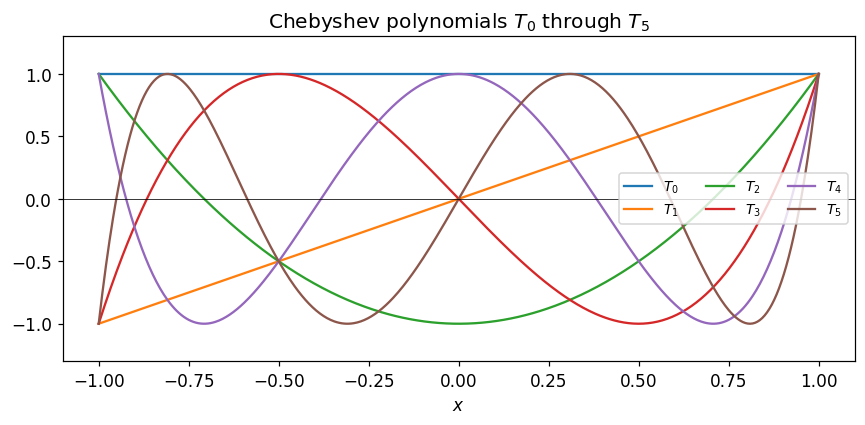

In [2]:
def chebyshev_poly(n, x):
    """Evaluate T_n via three-term recurrence — O(n) per point."""
    if n == 0:
        return np.ones_like(x, dtype=float)
    if n == 1:
        return np.asarray(x, dtype=float)
    T_prev, T_curr = np.ones_like(x, dtype=float), np.asarray(x, dtype=float)
    for _ in range(2, n + 1):
        T_prev, T_curr = T_curr, 2 * x * T_curr - T_prev
    return T_curr

x = np.linspace(-1, 1, 600)
fig, ax = plt.subplots(figsize=(8, 4))
for n in range(6):
    ax.plot(x, chebyshev_poly(n, x), label=f'$T_{n}$')
ax.axhline(0, color='k', lw=0.5)
ax.set_ylim(-1.3, 1.3)
ax.set_xlabel('$x$')
ax.set_title('Chebyshev polynomials $T_0$ through $T_5$')
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

### 1.3  Roots and extrema

**Zeros** (Chebyshev nodes of the first kind) — there are exactly $n$ in $(-1,1)$:

$$\boxed{x_k^{(n)} = \cos\!\left(\frac{(2k-1)\pi}{2n}\right), \quad k=1,\ldots,n.}$$

**Extrema** (Chebyshev nodes of the second kind, also called Gauss-Lobatto points):

$$\tilde{x}_k^{(n)} = \cos\!\left(\frac{k\pi}{n}\right), \quad k=0,\ldots,n.$$

At these points $T_n(\tilde{x}_k)=(-1)^k$, so $|T_n|$ reaches its maximum value of 1
at $n+1$ alternating points — this **equioscillation** is the key to the minimax
property.

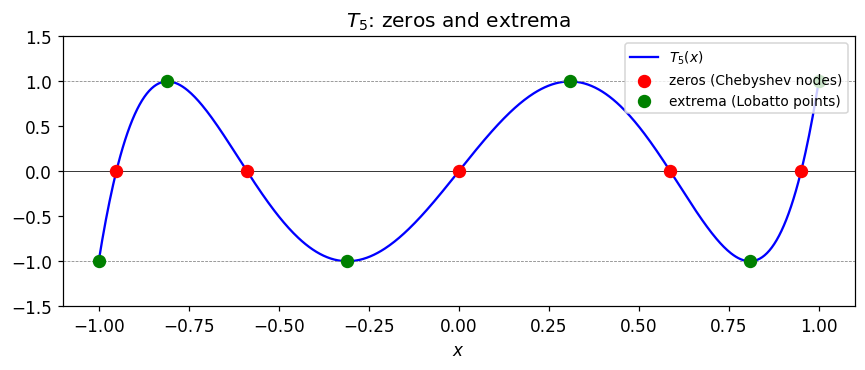

Chebyshev nodes (zeros of T_5): [-9.51056516e-01 -5.87785252e-01  6.12323400e-17  5.87785252e-01
  9.51056516e-01]
Values at extrema: [ 1. -1.  1. -1.  1. -1.]


In [3]:
n = 5
k = np.arange(1, n + 1)
zeros   = np.cos((2*k - 1) * np.pi / (2*n))          # roots of T_n
k2 = np.arange(0, n + 1)
extrema = np.cos(k2 * np.pi / n)                       # extrema of T_n

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(x, chebyshev_poly(n, x), 'b-', label=f'$T_{n}(x)$')
ax.scatter(zeros,   np.zeros(n),              color='red',   zorder=5,
           label='zeros (Chebyshev nodes)', s=60)
ax.scatter(extrema, chebyshev_poly(n, extrema), color='green', zorder=5,
           label='extrema (Lobatto points)', s=60)
ax.axhline(0,  color='k', lw=0.5)
ax.axhline( 1, color='grey', lw=0.5, ls='--')
ax.axhline(-1, color='grey', lw=0.5, ls='--')
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('$x$')
ax.set_title(f'$T_{n}$: zeros and extrema')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Chebyshev nodes (zeros of T_{n}): {np.sort(zeros)}')
print(f'Values at extrema: {chebyshev_poly(n, extrema)}')

### 1.4  Orthogonality

With weight $w(x) = (1-x^2)^{-1/2}$ on $[-1,1]$:

$$\int_{-1}^{1} T_m(x)\,T_n(x)\,\frac{dx}{\sqrt{1-x^2}}
= \begin{cases} 0 & m\neq n \\ \pi/2 & m=n\neq 0 \\ \pi & m=n=0. \end{cases}$$

**Proof sketch** — substitute $x=\cos\theta$, $dx = -\sin\theta\,d\theta$:
the integral becomes $\int_0^\pi \cos(m\theta)\cos(n\theta)\,d\theta$,
which is the standard $L^2[0,\pi]$ inner product of cosines.

**Discrete orthogonality** (used in FFT-based Chebyshev fitting) —
at the $m$ Chebyshev nodes $x_j = \cos\bigl((2j-1)\pi/(2m)\bigr)$:

$$\sum_{j=1}^{m} T_r(x_j)\,T_s(x_j)
= \begin{cases} 0 & r\neq s \\ m/2 & r=s\neq 0 \\ m & r=s=0. \end{cases}$$

This discrete version lets us compute Chebyshev coefficients exactly
(rather than integrating) when data live at Chebyshev nodes.

### 1.5  The minimax (best uniform approximation) property

**Theorem (Burden & Burden, §8.3 / Chebyshev 1853)**

> Among all monic polynomials $p_n$ of degree $n$, the one with
> the smallest sup-norm on $[-1,1]$ is
> $$\tilde{T}_n(x) = \frac{T_n(x)}{2^{n-1}}, \qquad
> \left\|\tilde{T}_n\right\|_\infty = \frac{1}{2^{n-1}}.$$

**Why?**  The equioscillation theorem (Chebyshev / Borel-Chebyshev)
states that the best approximation to the *zero function* by a monic
polynomial is the unique polynomial whose error oscillates between
$+\!M$ and $-\!M$ at least $n+1$ times.  $\tilde{T}_n$ achieves
exactly $n+1$ alternating extrema of $\pm 1/2^{n-1}$.

**Interpolation error consequence** — if we interpolate $f\in C^n[-1,1]$
at $n$ nodes $x_1,\ldots,x_n$ then

$$\max_{x\in[-1,1]}\!|f(x)-p_{n-1}(x)|
= \frac{|f^{(n)}(\xi)|}{n!}\,|\omega_n(x)|,
\quad \omega_n(x)=\prod_{k=1}^n(x-x_k).$$

To minimise the error bound we minimise $\|\omega_n\|_\infty$,
and the minimax theorem tells us the **optimal choice is the $n$ zeros
of $T_n$**.

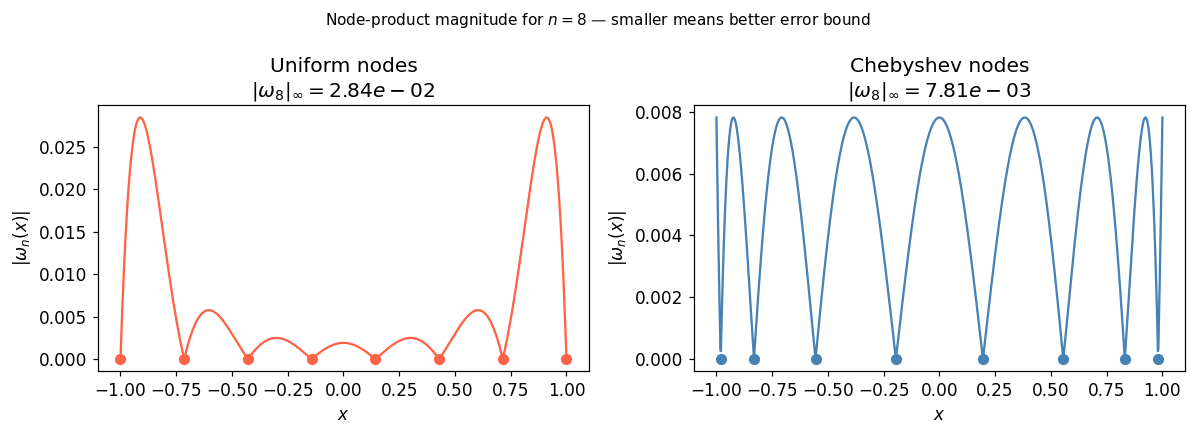

In [4]:
# Compare the node-product |ω_n(x)| for uniform vs Chebyshev nodes
n = 8
x_fine = np.linspace(-1, 1, 1000)

nodes_uniform = np.linspace(-1, 1, n)
nodes_cheb    = np.cos((2*np.arange(1, n+1) - 1) * np.pi / (2*n))

def omega(x, nodes):
    return np.prod([x - xi for xi in nodes], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
for ax, nodes, label, color in zip(
        axes,
        [nodes_uniform, nodes_cheb],
        ['Uniform nodes', 'Chebyshev nodes'],
        ['tomato', 'steelblue']):
    om = omega(x_fine, nodes)
    ax.plot(x_fine, np.abs(om), color=color)
    ax.scatter(nodes, np.zeros(n), color=color, zorder=5, s=40)
    ax.set_title(f'{label}\n$\\|\\omega_{n}\\|_\\infty = {np.max(np.abs(om)):.2e}$')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$|\\omega_n(x)|$')
plt.suptitle(f'Node-product magnitude for $n={n}$ — smaller means better error bound',
             fontsize=10)
plt.tight_layout()
plt.show()

### 1.6  Runge's phenomenon — uniform vs Chebyshev interpolation

The classic counter-example: $f(x)=\dfrac{1}{1+25x^2}$ (Runge 1901).
Polynomial interpolation at **uniform** nodes diverges near $\pm 1$
as $n$ grows.  Interpolating at **Chebyshev nodes** cures this.

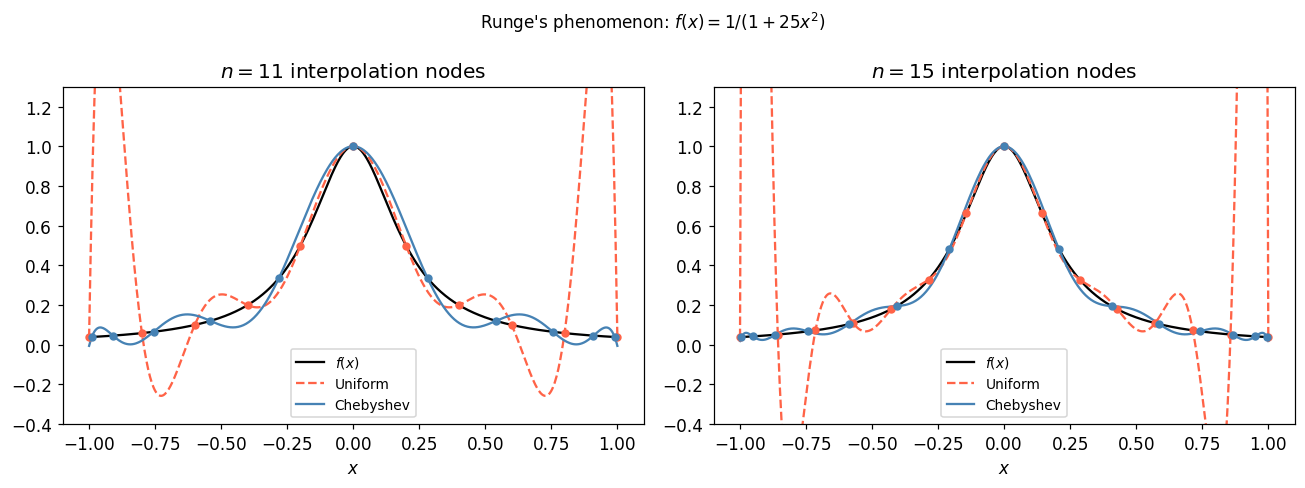

In [5]:
f = lambda x: 1.0 / (1 + 25 * x**2)
x_fine = np.linspace(-1, 1, 600)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, n_interp, color, label in zip(
        [axes[0], axes[1]],
        [11, 15],
        ['tomato', 'steelblue'],
        [11, 15]):
    nodes_u = np.linspace(-1, 1, n_interp)
    nodes_c = np.cos((2*np.arange(1, n_interp+1) - 1) * np.pi / (2*n_interp))

    p_u = np.polyfit(nodes_u, f(nodes_u), n_interp - 1)
    p_c = np.polyfit(nodes_c, f(nodes_c), n_interp - 1)

    ax.plot(x_fine, f(x_fine),            'k-',  lw=1.5, label='$f(x)$')
    ax.plot(x_fine, np.polyval(p_u, x_fine), '--', color='tomato',   label='Uniform')
    ax.plot(x_fine, np.polyval(p_c, x_fine), '-',  color='steelblue', label='Chebyshev')
    ax.scatter(nodes_u, f(nodes_u), color='tomato',   s=20, zorder=5)
    ax.scatter(nodes_c, f(nodes_c), color='steelblue', s=20, zorder=5)
    ax.set_ylim(-0.4, 1.3)
    ax.set_title(f'$n={n_interp}$ interpolation nodes')
    ax.set_xlabel('$x$')
    ax.legend(fontsize=9)
plt.suptitle("Runge's phenomenon: $f(x)=1/(1+25x^2)$", fontsize=11)
plt.tight_layout()
plt.show()

### 1.7  Chebyshev series expansion

Any $f\in C[-1,1]$ can be expanded as

$$f(x) \approx \sum_{k=0}^{N} {}^{\prime}\, c_k\, T_k(x),$$

where the prime denotes that the $k=0$ term is halved, and

$$c_k = \frac{2}{N}\sum_{j=1}^{N} f(x_j)\,T_k(x_j),
\quad x_j = \cos\!\left(\frac{(2j-1)\pi}{2N}\right).$$

The key fact: coefficients $c_k$ **decay rapidly** when $f$ is smooth,
so we need far fewer terms than a Taylor series for the same accuracy.

**Worked example — approximate $f(x)=e^x$ on $[-1,1]$ with degree 6**

True Taylor series needs all terms up to $x^6/(6!)$ and beyond;
Chebyshev coefficients become negligible at $k=6$.

Chebyshev coefficients of e^x (highest to lowest degree):
  c_ 0 = +1.26606588
  c_ 1 = +1.13031821
  c_ 2 = +0.27149534
  c_ 3 = +0.04433685
  c_ 4 = +0.00547424
  c_ 5 = +0.00054293
  c_ 6 = +0.00004498
  c_ 7 = +0.00000320
  c_ 8 = +0.00000020
  c_ 9 = +0.00000001
  c_10 = +0.00000000


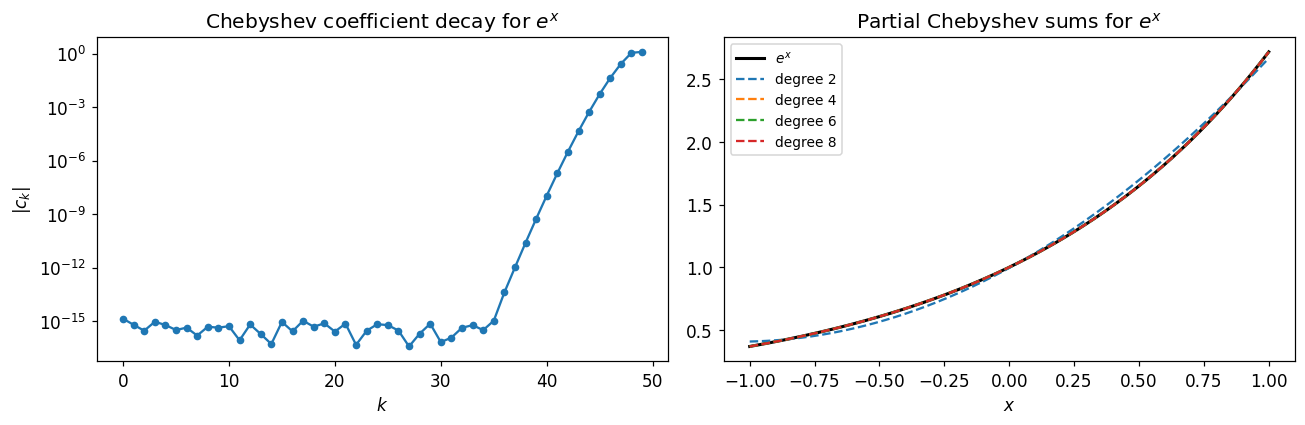

In [6]:
f = np.exp
x_fine = np.linspace(-1, 1, 600)

# Chebyshev expansion via NumPy
N_nodes = 50          # use many nodes for exact coefficient computation
nodes = np.cos((2*np.arange(1, N_nodes+1) - 1) * np.pi / (2*N_nodes))
c_all = chebfit(nodes, f(nodes), deg=N_nodes - 1)

print('Chebyshev coefficients of e^x (highest to lowest degree):')
c_display = chebfit(nodes, f(nodes), deg=10)   # degree-10 fit for display
for k, ck in enumerate(c_display):
    print(f'  c_{k:2d} = {ck:+.8f}')

# Convergence of partial sums
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogy(range(len(c_all)), np.abs(c_all[::-1]), 'o-', ms=4)
axes[0].set_xlabel('$k$')
axes[0].set_ylabel('$|c_k|$')
axes[0].set_title('Chebyshev coefficient decay for $e^x$')

axes[1].plot(x_fine, f(x_fine), 'k-', lw=2, label='$e^x$')
for deg in [2, 4, 6, 8]:
    c_deg = chebfit(nodes, f(nodes), deg=deg)
    axes[1].plot(x_fine, chebval(x_fine, c_deg), '--', label=f'degree {deg}')
axes[1].set_xlabel('$x$')
axes[1].set_title('Partial Chebyshev sums for $e^x$')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

### 1.8  Economisation of power series (Burden & Burden, §8.3)

Given a truncated Taylor polynomial $p_n(x)$, we can **reduce the degree
by one** while keeping the error small by subtracting $a_n\tilde{T}_n(x)$
(where $a_n$ is the leading coefficient), because $\tilde{T}_n$ is the
monic polynomial of smallest sup-norm.

**Example — economise the degree-4 Taylor polynomial of $e^x$:**

$$e^x \approx 1 + x + \tfrac{x^2}{2} + \tfrac{x^3}{6} + \tfrac{x^4}{24}$$

Remove $\dfrac{1}{24}\tilde{T}_4(x) = \dfrac{1}{24}\cdot\dfrac{T_4(x)}{8}
= \dfrac{8x^4 - 8x^2 + 1}{192}$ to obtain a degree-3 polynomial that
approximates $e^x$ with error bounded by $\dfrac{1}{2^3 \cdot 24} = \dfrac{1}{192}$.

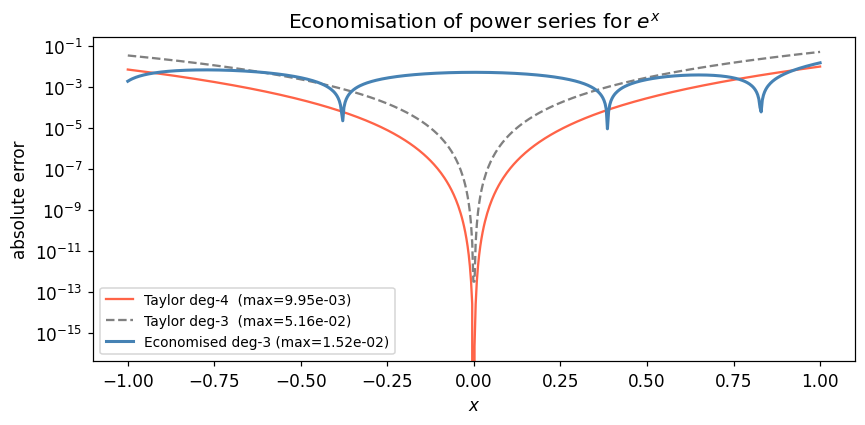

Error bound from theory: 1/192 = 0.005208
Actual max error (economised): 0.015157


In [7]:
x_fine = np.linspace(-1, 1, 600)
f = np.exp

# Taylor degree-4 and degree-3 reference
p4_coeffs = np.array([1/24, 1/6, 1/2, 1, 1])   # a4 x^4 + ... + a0  (numpy poly highest first)
p3_coeffs = np.array([1/6, 1/2, 1, 1])

# Economised degree-3: subtract (1/24) * T_4(x)/8 = (8x^4-8x^2+1)/192
T4_coeffs = np.array([8, 0, -8, 0, 1]) / 8     # monic T_4/8
econ3_coeffs = p4_coeffs - (1/24) * T4_coeffs  # leading x^4 term cancels
econ3_coeffs = econ3_coeffs[1:]                 # drop the now-zero x^4 coefficient

err_p4   = np.max(np.abs(f(x_fine) - np.polyval(p4_coeffs,   x_fine)))
err_p3   = np.max(np.abs(f(x_fine) - np.polyval(p3_coeffs,   x_fine)))
err_econ = np.max(np.abs(f(x_fine) - np.polyval(econ3_coeffs, x_fine)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(x_fine, np.abs(f(x_fine) - np.polyval(p4_coeffs,   x_fine)),
            label=f'Taylor deg-4  (max={err_p4:.2e})', color='tomato')
ax.semilogy(x_fine, np.abs(f(x_fine) - np.polyval(p3_coeffs,   x_fine)),
            label=f'Taylor deg-3  (max={err_p3:.2e})', color='grey', ls='--')
ax.semilogy(x_fine, np.abs(f(x_fine) - np.polyval(econ3_coeffs, x_fine)),
            label=f'Economised deg-3 (max={err_econ:.2e})', color='steelblue', lw=2)
ax.set_xlabel('$x$')
ax.set_ylabel('absolute error')
ax.set_title('Economisation of power series for $e^x$')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Error bound from theory: 1/192 = {1/192:.6f}')
print(f'Actual max error (economised): {err_econ:.6f}')

---
## Part 2 — Fast Fourier Transform

### 2.1  Trigonometric interpolation (Burden & Burden, §8.6)

Given $N=2m$ equally-spaced data points $\{(x_j, y_j)\}_{j=0}^{N-1}$
on $[0, 2\pi)$ with $x_j = 2\pi j/N$, we seek a trigonometric polynomial

$$S_N(x) = \frac{a_0}{2} + \sum_{k=1}^{m-1}\bigl[a_k\cos(kx)+b_k\sin(kx)\bigr]
+ \frac{a_m}{2}\cos(mx),$$

which has $N$ free coefficients and passes through all $N$ data points.

### 2.2  Discrete Fourier Transform (DFT)

Define the **DFT** of $(y_0,\ldots,y_{N-1})$ as

$$c_k = \frac{1}{N}\sum_{j=0}^{N-1} y_j\, e^{-2\pi i\,jk/N},
\qquad k=0,1,\ldots,N-1.$$

Let $\omega_N = e^{-2\pi i/N}$ (primitive $N$-th root of unity). Then:

$$\mathbf{c} = \frac{1}{N}\,F_N\,\mathbf{y}, \qquad
(F_N)_{jk} = \omega_N^{jk}.$$

The coefficients of $S_N$ are recovered from $c_k$ via

$$a_k = 2\,\operatorname{Re}(c_k), \quad b_k = -2\,\operatorname{Im}(c_k),
\quad a_0 = 2\,\operatorname{Re}(c_0), \quad a_m = 2\,\operatorname{Re}(c_m).$$

**Complexity:** naive DFT requires $O(N^2)$ multiplications.
The **FFT** computes the same result in $O(N\log_2 N)$.

In [8]:
def dft_naive(y):
    """O(N^2) DFT for comparison with FFT."""
    N = len(y)
    omega = np.exp(-2j * np.pi / N)
    F = np.array([[omega**(j*k) for k in range(N)] for j in range(N)])
    return F @ y / N

# Verify against numpy FFT on a small example
N = 8
y = np.random.default_rng(42).standard_normal(N)
c_naive = dft_naive(y)
c_numpy = np.fft.fft(y) / N
print('Max difference naive DFT vs numpy FFT:', np.max(np.abs(c_naive - c_numpy)))

Max difference naive DFT vs numpy FFT: 1.1389935954777104e-15


### 2.3  The Cooley-Tukey FFT algorithm (radix-2)

The key insight (Cooley & Tukey 1965, though Gauss knew it ~1805) is that
when $N=2^s$ we can split the DFT into two half-size DFTs:

$$c_k = \underbrace{\frac{1}{N}\sum_{j=0}^{N/2-1} y_{2j}\,\omega_N^{2jk}}_{\text{DFT of even-indexed}}
+ \omega_N^k\underbrace{\frac{1}{N}\sum_{j=0}^{N/2-1} y_{2j+1}\,\omega_N^{2jk}}_{\text{DFT of odd-indexed}}.$$

Since $\omega_N^2 = \omega_{N/2}$, each half is a DFT of size $N/2$.
Applying this recursively gives the butterfly diagram and the
$O(N\log_2 N)$ cost.

**Recurrence for operation count** $T(N)$:

$$T(N) = 2\,T(N/2) + N \implies T(N) = \tfrac{N}{2}\log_2 N.$$

**Example** — $N=10^6$: naive DFT needs $10^{12}$ ops; FFT needs only $10^7$.

N=64: max |FFT_recursive - numpy FFT| = 7.85e-17


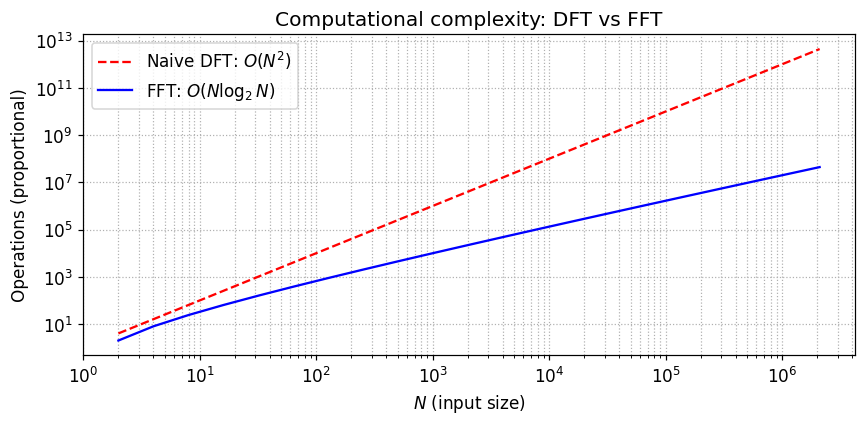

In [9]:
def fft_recursive(y):
    """Cooley-Tukey radix-2 FFT — N must be a power of 2."""
    N = len(y)
    if N == 1:
        return y.astype(complex)
    even = fft_recursive(y[::2])
    odd  = fft_recursive(y[1::2])
    twiddle = np.exp(-2j * np.pi * np.arange(N // 2) / N)
    return np.concatenate([even + twiddle * odd,
                           even - twiddle * odd])

N = 64
y = np.random.default_rng(0).standard_normal(N)
c_recursive = fft_recursive(y) / N
c_numpy     = np.fft.fft(y) / N
print(f'N={N}: max |FFT_recursive - numpy FFT| = {np.max(np.abs(c_recursive - c_numpy)):.2e}')

# Operation count comparison
ns = np.array([2**k for k in range(1, 22)])
fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(ns, ns**2,            'r--', label='Naive DFT: $O(N^2)$')
ax.loglog(ns, ns * np.log2(ns), 'b-',  label='FFT: $O(N\\log_2 N)$')
ax.set_xlabel('$N$ (input size)')
ax.set_ylabel('Operations (proportional)')
ax.set_title('Computational complexity: DFT vs FFT')
ax.legend()
ax.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

### 2.4  Trigonometric interpolation — worked example

We reconstruct
$f(x) = \sin x + \tfrac{1}{3}\sin 3x + \tfrac{1}{5}\sin 5x$
(partial Fourier series of a square wave)
from $N=16$ equally-spaced samples.

**Algorithm (Burden & Burden, §8.6 Algorithm 8.3):**
1. Sample $y_j = f(2\pi j/N)$ for $j=0,\ldots,N-1$.
2. Compute $\mathbf{c} = \text{FFT}(\mathbf{y})/N$.
3. Recover $a_k = 2\operatorname{Re}(c_k)$, $b_k = -2\operatorname{Im}(c_k)$.
4. Evaluate $S_N(x)$ at any $x$.

Fourier coefficients recovered by FFT:
  a_0 = -0.000000   (expect 0)
  a_1 = -0.000000   b_1 = +1.000000
  a_2 = -0.000000   b_2 = +0.000000
  a_3 = -0.000000   b_3 = +0.333333
  a_4 = +0.000000   b_4 = +0.000000
  a_5 = -0.000000   b_5 = +0.200000
  a_6 = +0.000000   b_6 = +0.000000
  a_7 = +0.000000   b_7 = -0.000000
  a_8 = +0.000000   b_8 = -0.000000


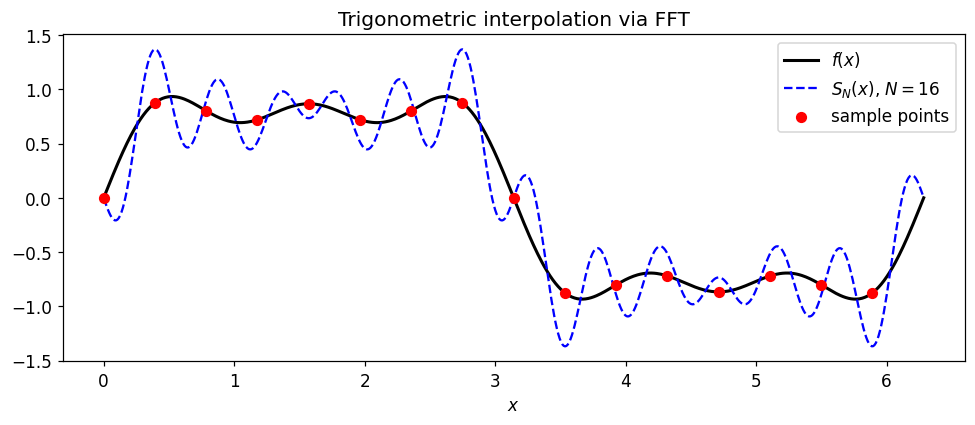


Max interpolation error on [0, 2π]: 5.29e-01


In [10]:
f = lambda x: np.sin(x) + np.sin(3*x)/3 + np.sin(5*x)/5

N = 16
m = N // 2
x_nodes = 2 * np.pi * np.arange(N) / N       # equally-spaced on [0, 2π)
y       = f(x_nodes)

c = np.fft.fft(y) / N
a = 2 * np.real(c)
b = -2 * np.imag(c)
a[0] /= 2          # a_0/2 convention
a[m] /= 2          # a_m/2 convention

print('Fourier coefficients recovered by FFT:')
print(f'  a_0 = {a[0]:.6f}   (expect 0)')
for k in range(1, m + 1):
    print(f'  a_{k} = {a[k]:+.6f}   b_{k} = {b[k]:+.6f}')

def S_N(x_eval, a, b):
    """Evaluate the trigonometric interpolant at x_eval."""
    m = len(a) - 1
    result = a[0] * np.ones_like(x_eval)
    for k in range(1, m):
        result += a[k] * np.cos(k * x_eval) + b[k] * np.sin(k * x_eval)
    result += a[m] * np.cos(m * x_eval)
    return result

x_fine = np.linspace(0, 2 * np.pi, 600)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_fine, f(x_fine), 'k-', lw=2, label='$f(x)$')
ax.plot(x_fine, S_N(x_fine, a, b), 'b--', lw=1.5, label=f'$S_{{N}}(x)$, $N={N}$')
ax.scatter(x_nodes, y, color='red', zorder=5, s=40, label='sample points')
ax.set_xlabel('$x$')
ax.set_title('Trigonometric interpolation via FFT')
ax.legend()
plt.tight_layout()
plt.show()

err = np.max(np.abs(f(x_fine) - S_N(x_fine, a, b)))
print(f'\nMax interpolation error on [0, 2π]: {err:.2e}')

### 2.5  Effect of $N$ on trigonometric interpolation error

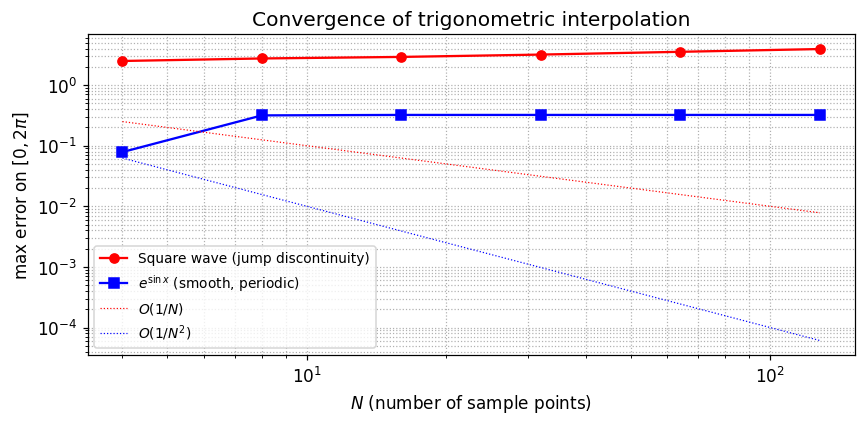

In [11]:
f_sq = lambda x: np.sign(np.sin(x))       # square wave — has jump discontinuities
f_sm = lambda x: np.exp(np.sin(x))        # smooth periodic function
x_fine = np.linspace(0, 2 * np.pi, 4000)

Ns = [4, 8, 16, 32, 64, 128]
errors = {'square wave': [], 'smooth': []}

for N in Ns:
    m = N // 2
    xn = 2 * np.pi * np.arange(N) / N
    for fname, f in [('square wave', f_sq), ('smooth', f_sm)]:
        y  = f(xn)
        c  = np.fft.fft(y) / N
        ak = 2 * np.real(c); bk = -2 * np.imag(c)
        ak[0] /= 2; ak[m] /= 2
        err = np.max(np.abs(f(x_fine) - S_N(x_fine, ak, bk)))
        errors[fname].append(err)

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(Ns, errors['square wave'], 'r-o', label='Square wave (jump discontinuity)')
ax.loglog(Ns, errors['smooth'],      'b-s', label='$e^{\\sin x}$ (smooth, periodic)')
# Reference lines
ax.loglog(Ns, [1/n for n in Ns], 'r:', lw=0.8, label='$O(1/N)$')
ax.loglog(Ns, [1/n**2 for n in Ns], 'b:', lw=0.8, label='$O(1/N^2)$')
ax.set_xlabel('$N$ (number of sample points)')
ax.set_ylabel('max error on $[0, 2\\pi]$')
ax.set_title('Convergence of trigonometric interpolation')
ax.legend(fontsize=9)
ax.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

The convergence plot illustrates a key theorem:

| Smoothness of $f$ | Rate of convergence |
|-------------------|---------------------|
| $f$ has a jump discontinuity | $O(1/N)$ — **Gibbs phenomenon** |
| $f\in C^p$, $2\pi$-periodic | $O(1/N^p)$ |
| $f$ is real-analytic | **spectral** (exponential in $N$) |

### 2.6  Gibbs phenomenon

Near a jump discontinuity the trigonometric interpolant **overshoots** by
approximately $9\%$ of the jump height, regardless of $N$.
This is unavoidable when using a finite Fourier series at a genuine discontinuity.

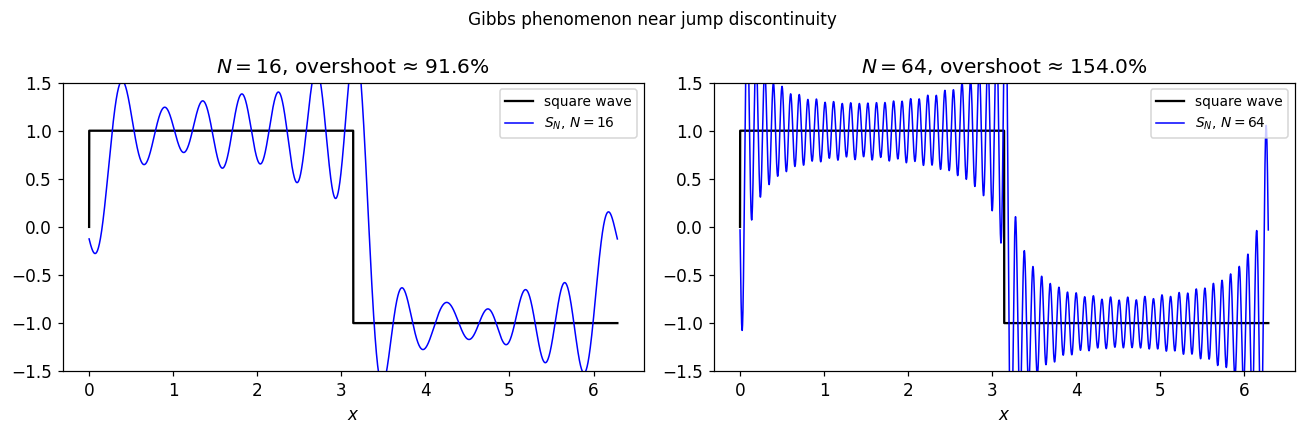

In [12]:
x_fine = np.linspace(0, 2*np.pi, 4000)
f_sq = lambda x: np.sign(np.sin(x))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, N in zip(axes, [16, 64]):
    m = N // 2
    xn = 2 * np.pi * np.arange(N) / N
    y  = f_sq(xn)
    c  = np.fft.fft(y) / N
    ak = 2 * np.real(c); bk = -2 * np.imag(c)
    ak[0] /= 2; ak[m] /= 2
    s = S_N(x_fine, ak, bk)
    overshoot = (np.max(s) - 1.0) * 100
    ax.plot(x_fine, f_sq(x_fine), 'k-', lw=1.5, label='square wave')
    ax.plot(x_fine, s, 'b-', lw=1, label=f'$S_{{N}}$, $N={N}$')
    ax.set_ylim(-1.5, 1.5)
    ax.set_title(f'$N={N}$, overshoot ≈ {overshoot:.1f}%')
    ax.set_xlabel('$x$')
    ax.legend(fontsize=9)
plt.suptitle('Gibbs phenomenon near jump discontinuity', fontsize=11)
plt.tight_layout()
plt.show()

### 2.7  Timing: FFT vs naive DFT

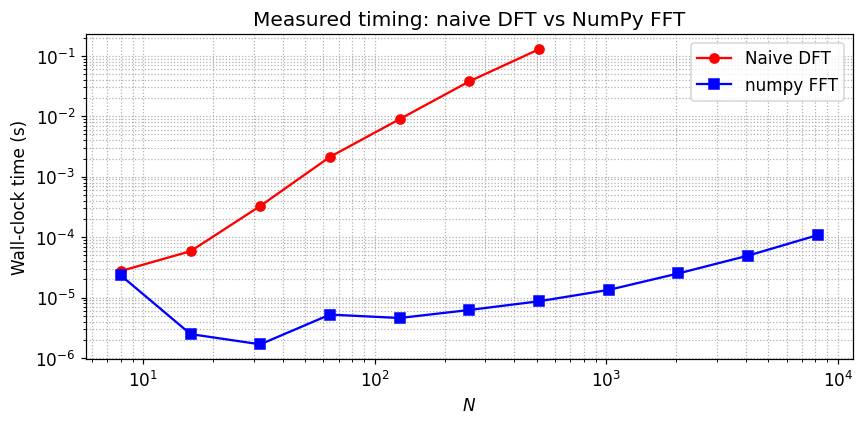

In [13]:
import time

sizes = [2**k for k in range(3, 14)]
times_naive, times_fft = [], []

rng = np.random.default_rng(7)
for N in sizes:
    y = rng.standard_normal(N)

    # naive DFT (only for smaller sizes)
    if N <= 512:
        t0 = time.perf_counter()
        for _ in range(5): dft_naive(y)
        times_naive.append((time.perf_counter() - t0) / 5)
    else:
        times_naive.append(None)

    t0 = time.perf_counter()
    for _ in range(50): np.fft.fft(y)
    times_fft.append((time.perf_counter() - t0) / 50)

fig, ax = plt.subplots(figsize=(8, 4))
valid = [(n, t) for n, t in zip(sizes, times_naive) if t is not None]
if valid:
    ns_v, ts_v = zip(*valid)
    ax.loglog(ns_v, ts_v, 'r-o', label='Naive DFT')
ax.loglog(sizes, times_fft, 'b-s', label='numpy FFT')
ax.set_xlabel('$N$')
ax.set_ylabel('Wall-clock time (s)')
ax.set_title('Measured timing: naive DFT vs NumPy FFT')
ax.legend()
ax.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

---
## Part 3 — Exercises

### Exercise 1  (Chebyshev nodes)

Let $f(x)=\ln(x+2)$ on $[-1,1]$.

(a) Interpolate $f$ at $n=6$ **uniform** nodes and at $n=6$ **Chebyshev nodes**.  
(b) Plot both interpolating polynomials alongside $f$.  
(c) Compute and compare the maximum error on $[-1,1]$ for each.

### Exercise 2  (Chebyshev series)

Use `numpy.polynomial.chebyshev.chebfit` to find the degree-$k$ Chebyshev
expansion of $f(x)=|x|$ on $[-1,1]$ for $k=3,5,9,19$.  
Note the slow decay of coefficients — why is this expected for a function
that is only $C^0$ but not $C^1$?

### Exercise 3  (Economisation)

The degree-5 Taylor polynomial of $\cos x$ on $[-1,1]$ is
$p_5(x) = 1 - x^2/2 + x^4/24$.  
Economise by one degree using $T_5$, and compare the maximum error of
$p_5$ with the economised $p_4$ on $[-1,1]$.

### Exercise 4  (FFT — Burden & Burden §8.6, Problem 3)

Apply the FFT to the data
$y_j = f(x_j)$ where $x_j = j\pi/4$ for $j=0,1,\ldots,7$ and
$f(x) = \sin x + \cos 2x$.  
(a) Compute the DFT coefficients.  
(b) Recover $a_k$ and $b_k$.  
(c) Compare the recovered trigonometric polynomial with $f$ on $[0,2\pi]$.

### Exercise 5  (Gibbs, conceptual)

Explain in one paragraph why the $\approx 9\%$ Gibbs overshoot does **not**
decrease as $N\to\infty$, even though more frequency components are included.
What is the mathematical mechanism?

---
## Summary

| Concept | Key result |
|---------|------------|
| Chebyshev polynomial | $T_n(x)=\cos(n\arccos x)$; recurrence $T_{n+1}=2xT_n-T_{n-1}$ |
| Chebyshev nodes | $x_k=\cos\bigl(\tfrac{(2k-1)\pi}{2n}\bigr)$ — zeros of $T_n$ |
| Minimax theorem | $\tilde{T}_n=T_n/2^{n-1}$ minimises $\|p_n\|_\infty$ among monic polynomials |
| Error reduction | Using Chebyshev nodes eliminates Runge's phenomenon |
| Economisation | Subtract $c_n\tilde{T}_n$ to reduce degree while bounding added error |
| DFT | $c_k = N^{-1}\sum_j y_j\,e^{-2\pi ijk/N}$ — $O(N^2)$ cost |
| FFT | Cooley-Tukey radix-2 recursion — reduces cost to $O(N\log_2 N)$ |
| Convergence | Smooth periodic: spectral; discontinuous: $O(1/N)$ + Gibbs $9\%$ overshoot |

**Key references**
- Burden, R. L. & Burden, A. J., *Numerical Analysis*, 10th ed., §8.2–8.3, §8.6.
- Trefethen, L. N., *Approximation Theory and Approximation Practice*, SIAM, 2013 (open access).
- Cooley, J. W. & Tukey, J. W., *Math. Comp.* **19** (1965), pp. 297–301.